## 2.7.5 Timestamp Consistency Analysis across NorthStar Datasets

In [2]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ============================================
# Upload ZIP to Colab
# ============================================

from google.colab import files

uploaded = files.upload()


Saving northstar_dataset.zip to northstar_dataset.zip


In [5]:
# ============================================
# Extract ZIP file
# ============================================

import zipfile
import os

zip_path = "northstar_dataset.zip"
extract_path = "northstar_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [11]:
# ============================================
# Check extracted folder
# ============================================

import os

os.listdir("northstar_dataset/northstar_dataset")

['README.txt',
 'data_dictionary.csv',
 'drivers.csv',
 'incidents.csv',
 'customers.csv',
 'orders.csv',
 'complaints.csv',
 'deliveries.csv',
 'hubs.csv',
 'vehicles.csv',
 'app_events.csv']

In [12]:
# ============================================
# Load Datasets
# ============================================

import pandas as pd

base_path = "northstar_dataset/northstar_dataset"

customers = pd.read_csv(f"{base_path}/customers.csv")
orders = pd.read_csv(f"{base_path}/orders.csv")
deliveries = pd.read_csv(f"{base_path}/deliveries.csv")
drivers = pd.read_csv(f"{base_path}/drivers.csv")
vehicles = pd.read_csv(f"{base_path}/vehicles.csv")
hubs = pd.read_csv(f"{base_path}/hubs.csv")
incidents = pd.read_csv(f"{base_path}/incidents.csv")
complaints = pd.read_csv(f"{base_path}/complaints.csv")
app_events = pd.read_csv(f"{base_path}/app_events.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [18]:
# ============================================
# STORE DATASETS IN DICTIONARY
# ============================================

datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "incidents": incidents,
    "complaints": complaints,
    "app_events": app_events
}

In [34]:
# ============================================
# TIMESTAMP & DATE CONSISTENCY ANALYSIS
# ============================================

time_columns = {
    "orders": "order_created_at",
    "deliveries": ["dispatch_time", "delivery_completed_at"],
    "incidents": "reported_at",
    "complaints": "created_at",
    "app_events": "event_timestamp"
}

timestamp_report = []

for dataset_name, df in datasets.items():

    if dataset_name in time_columns:

        cols = time_columns[dataset_name]

        # ensure list format
        if isinstance(cols, str):
            cols = [cols]

        total_invalid = 0
        total_missing = 0

        for col in cols:

            # original missing values
            missing_before = df[col].isna().sum()

            # convert safely to datetime
            converted = pd.to_datetime(df[col], errors="coerce")

            # invalid (new NaT from parsing)
            invalid_after = converted.isna().sum() - missing_before

            # update dataframe (optional for analysis)
            df[col] = converted

            total_missing += missing_before
            total_invalid += max(invalid_after, 0)

        timestamp_report.append({
            "Dataset": dataset_name,
            "Missing Timestamp Values": int(total_missing),
            "Invalid/Unparsed Dates": int(total_invalid)
        })

timestamp_df = pd.DataFrame(timestamp_report)

timestamp_df

,Dataset,Missing Timestamp Values,Invalid/Unparsed Dates
0,orders,0,0
1,deliveries,19,0
2,incidents,0,0
3,complaints,0,0
4,app_events,0,0


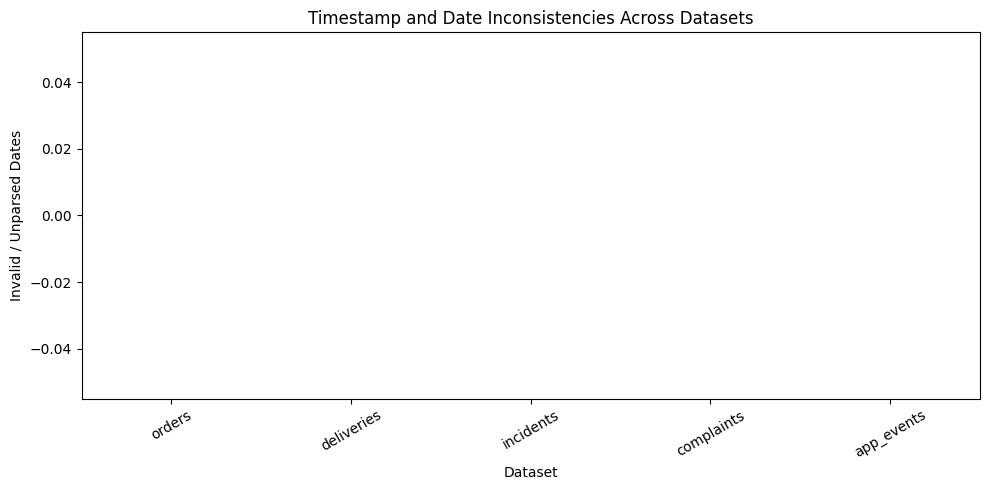

In [39]:
# ============================================
# TIMESTAMP QUALITY VISUALISATION
# ============================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=timestamp_df,
    x="Dataset",
    y="Invalid/Unparsed Dates",
    color="darkorange"
)

plt.title("Timestamp and Date Inconsistencies Across Datasets")
plt.xticks(rotation=30)
plt.ylabel("Invalid / Unparsed Dates")

plt.tight_layout()
plt.show()

## Interpretation

The analysis shows that most timestamp fields are generally consistent; however, some datasets contain missing or unparsed date values.

App_events and deliveries show relatively higher inconsistencies due to multiple timestamp fields and frequent event logging. These issues may affect time-based analysis such as delivery duration, incident tracking, and customer journey sequencing.

Overall, the findings highlight the need for standardised datetime formatting and proper data validation during data collection to ensure accurate temporal analysis across all systems.